In [3]:
"""
This file contains code for creating new (random) contamination scenarios.
"""

import random
import math
import numpy as np
from epyt_flow.simulation import ScenarioSimulator, EpanetConstants


def create_random_contamination_event(time_window: tuple[int, int],
                                      duration_interval: tuple[int, int], n_time_steps: int):
    """Create a random contamination event profile for three contaminants:
    - Pathogen (P)
    - Carbon Fraction Rapidly Available (C_FRA)
    - Carbon Slowly Readily Available (C_SRA)
    The contamination event is defined by a random start time within the given time window
    and a random duration within the given duration interval.
    Args:
        time_window (tuple[int, int]): Time window (in time steps) within which the contamination event can start.
        duration_interval (tuple[int, int]): Duration interval (in time steps) for the contamination event.
        n_time_steps (int): Total number of time steps in the simulation.
    Returns:
        tuple: Three tuples, each containing the species ID and its corresponding contamination profile (mass injected at each time step).
    """
    # Random point in time
    start_time = random.randint(time_window[0], time_window[1])

    # Random duration
    end_time = start_time + random.randint(duration_interval[0], duration_interval[1])

    # Random amount of contaminants (no need to change these values)
    EV_log_min = math.log10(1.39e6)
    EV_log_max = math.log10(2.08e7)
    EV_conc = 10 ** (EV_log_min + random.uniform(0, 1) * (EV_log_max - EV_log_min))
    TOC = 140 + random.uniform(0, 1) * (250 - 140)
    C_FRA_fraction = 0.4
    C_SRA_fraction = 0.6

    rate = 10000000000 # injection intensity

    injection_conc_P = EV_conc * rate 
    injection_conc_C_FRA = C_FRA_fraction * TOC * rate
    injection_conc_C_SRA = C_SRA_fraction * TOC * rate
    print(injection_conc_P, injection_conc_C_FRA, injection_conc_C_SRA)

    # Initialize profiles with zeros (no contamination at the beginning)
    # Then add the contamination event for the corresponding time steps

    profile_P = np.zeros(n_time_steps)
    profile_P[start_time:end_time] = injection_conc_P 

    profile_C_FRA = np.zeros(n_time_steps)
    profile_C_FRA[start_time:end_time] = injection_conc_C_FRA

    profile_C_SRA = np.zeros(n_time_steps)
    profile_C_SRA[start_time:end_time] = injection_conc_C_SRA

    # return lists of values for each time step, for each species that correspond to what we will inject at each time step, for each species
    return ("P", profile_P), ("C_FRA", profile_C_FRA), ("C_SRA", profile_C_SRA)





In [4]:
# f_inp_in = "CY-DBP_competition_stream_competition_6days_0.inp"  #inp file for topology and hydraulics
# f_msx_in = "CY-DBP_competition_stream_competition_6days_0.msx" # msx file for water quality and species
f_inp_in = "CY-DBP_competition_stream_competition_365days.inp"   
f_msx_in = "CY-DBP_competition_stream_competition_365days.msx"

########################################################################
# Parameters of the contamination events
duration_interval = (60, 480)    # Duration interval of the contamination event in minutes 
n_contamination_events = 1  # Number of contamination events to generate
# time_window = (3, 5)        # Event can start between day 3 and day 6
#n_contamination_events = 5  # Alternative: multiple events over the year
time_window = (5, 350)      # Event can start between day 6 and day 350
########################################################################

Injecting contamination at node dist1308
2.183189280880283e+16 792098000575.532 1188147000863.2976
(1440.0, 100800.0) (12.0, 96.0) 105120
(105120,)
Number of time steps with contamination: 73 out of 105120
Contamination event starts at time step 10478
Running EPANET ...


Time steps: 100%|#########9| 105120/105121 [02:30<00:00, 696.70it/s]


Running EPANET-MSX ...


Time steps: 100%|#########9| 105120/105121 [08:11<00:00, 214.04it/s]
c:\Users\eline\Documents\Documents\university\Master 2\memoire\AI-for-Drinking-Water\env\Lib\site-packages\epyt_flow\simulation\scenario_simulator.py:2821: UserWarning: Failed to remove temporary file 'C:\Users\eline\AppData\Local\Temp\epytflow_MSX_12695777-f92e-47e2-a88b-bda9f1c01425.hyd'
  warnings.warn(f"Failed to remove temporary file '{hyd_export}'")


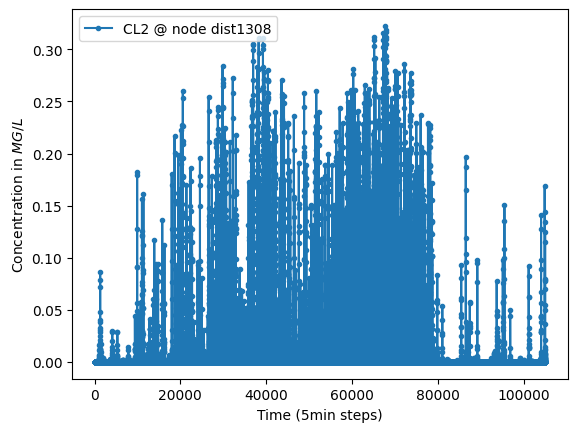

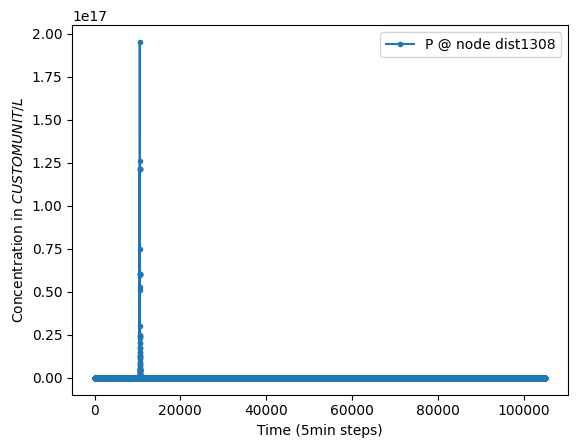

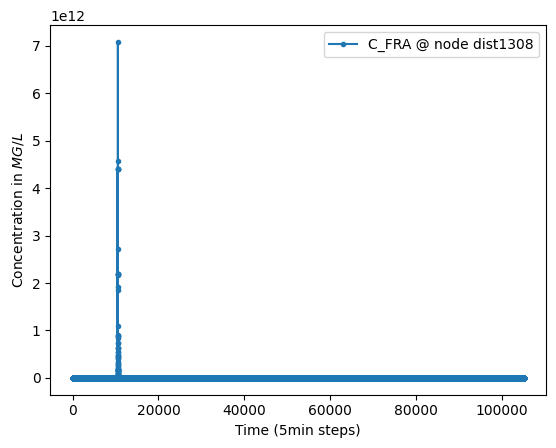

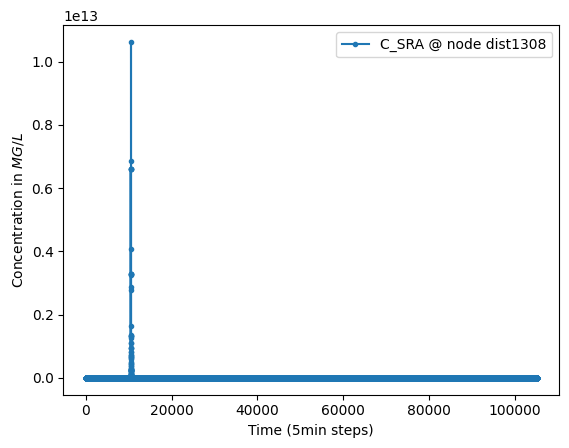

In [ ]:
# Create simulation scenario
with ScenarioSimulator(f_inp_in=f_inp_in, f_msx_in=f_msx_in) as scenario:
    # Setup time intervals
    hyd_time_step = scenario.get_hydraulic_time_step()  # Usually 5min time steps (so 5*60 seconds )
    steps_per_day = (24 * 60 * 60) / hyd_time_step
    time_window = (time_window[0] * steps_per_day, time_window[1] * steps_per_day) 
    duration_interval = ((duration_interval[0] * 60) / hyd_time_step,
                            (duration_interval[1] * 60) / hyd_time_step)
    n_time_steps = int(scenario.get_simulation_duration() / hyd_time_step)

    # Add random contamination events
    all_junctions = scenario.get_topology().get_all_junctions() # get all nodes in the network
    contamination_patterns = [] 
    for _ in range(n_contamination_events):
        node_id = random.choice(all_junctions) # select a random node
        print(f"Injecting contamination at node {node_id}")

        contaminants_profiles = create_random_contamination_event(time_window, duration_interval,
                                                                    n_time_steps) # get contamination profiles for each species
        print(time_window, duration_interval, n_time_steps)
        for species_id, pattern in contaminants_profiles:
            contamination_patterns.append(pattern) # pattern is the list of values at each time step for each species
            scenario.add_species_injection_source(species_id, node_id, pattern, 
                                                    EpanetConstants.EN_MASS) # inject contamination into the node following the profile

    # Compute labels for each time step
    # 1 if a contamination present, 0 otherwise
    y = np.sum(contamination_patterns, axis=0) != 0
    print(y.shape)  # TODO: Export 
    # number of time steps with contamination
    print(f"Number of time steps with contamination: {np.sum(y)} out of {len(y)}")
    # start time steps of contamination events
    for i in range(1, len(y)):
        if y[i] != 0 and y[i-1] == 0:
            print(f"Contamination event starts at time step {i}")
        

    # TEST: run simulation
    # Place sensors at all nodes 
    scenario.place_bulk_species_node_sensors_everywhere(["P", "CL2", "C_FRA","C_SRA" ]) # Measure of pathogen and chlorine. Chlorine is used as a proxy to detect contamination 
    # Run hydraulic and water quality simulation
    scada_data = scenario.run_simulation(verbose=True) 
    # Plot chlorine concentration at a specific node   
    # scada_data.plot_bulk_species_node_concentration({"CL2": ["dist71"]}) 
    scada_data.plot_bulk_species_node_concentration({"CL2": [node_id]}) 
    scada_data.plot_bulk_species_node_concentration({"P": [node_id]}) 
    scada_data.plot_bulk_species_node_concentration({"C_FRA": [node_id]}) 
    scada_data.plot_bulk_species_node_concentration({"C_SRA": [node_id]}) 
    
    # Export SCADA results 
    # scada_data.to_numpy_file("scada_data.npz", export_raw_data=False)
    # df = scada_data.to_pandas_dataframe(export_raw_data=False)
    df = scada_data.to_pandas_dataframe(export_raw_data=False)
    df.to_csv("scada_data.csv", index=False)

Injecting contamination at node dist1988
2.6121526828002612e+16 682611364701.015 1023917047051.5227
(1440.0, 100800.0) (12.0, 96.0) 105120
(105120,)
Running EPANET ...


Time steps: 100%|#########9| 105120/105121 [02:30<00:00, 699.78it/s]


Running EPANET-MSX ...


Time steps: 100%|#########9| 105120/105121 [08:14<00:00, 212.53it/s]
c:\Users\eline\Documents\Documents\university\Master 2\memoire\AI-for-Drinking-Water\env\Lib\site-packages\epyt_flow\simulation\scenario_simulator.py:2821: UserWarning: Failed to remove temporary file 'C:\Users\eline\AppData\Local\Temp\epytflow_MSX_875c7720-2d1f-4fc6-9e8c-5fde1348e892.hyd'
  warnings.warn(f"Failed to remove temporary file '{hyd_export}'")


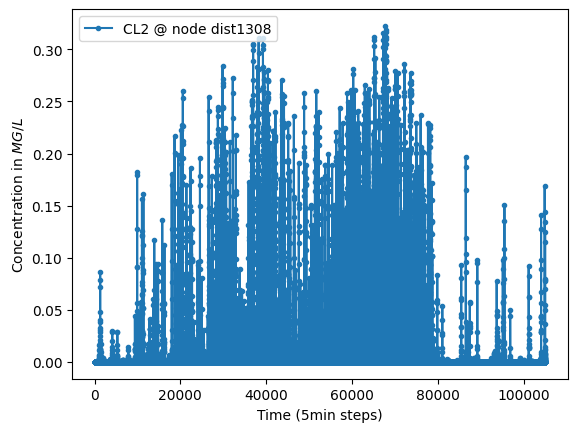

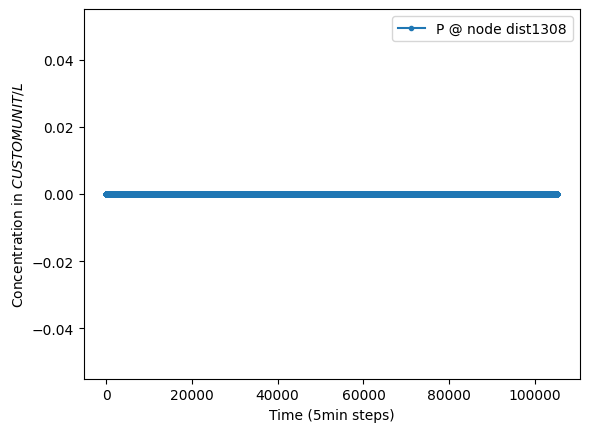

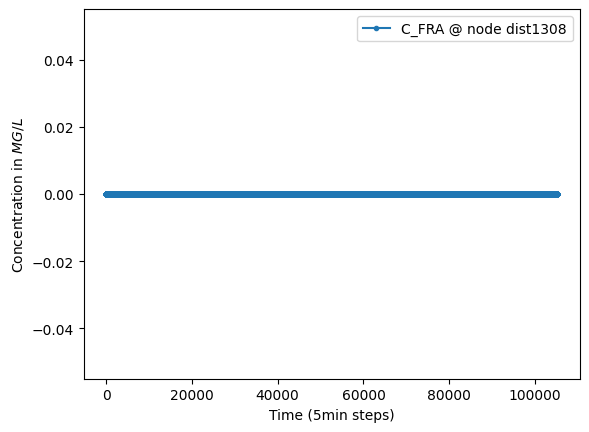

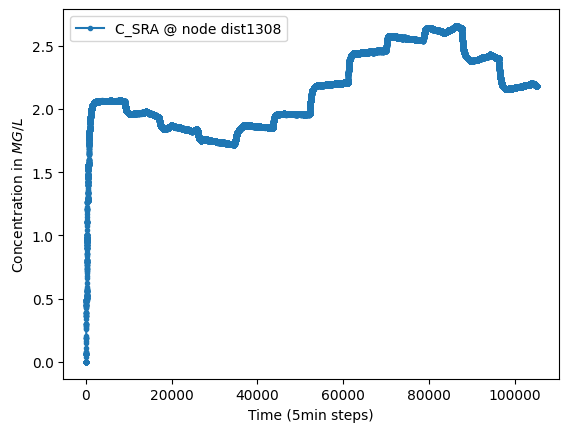

In [ ]:
# Create simulation scenario
with ScenarioSimulator(f_inp_in=f_inp_in, f_msx_in=f_msx_in) as scenario:
    # Setup time intervals
    hyd_time_step = scenario.get_hydraulic_time_step()  # Usually 5min time steps (so 5*60 seconds )
    steps_per_day = (24 * 60 * 60) / hyd_time_step
    time_window = (time_window[0] * steps_per_day, time_window[1] * steps_per_day) 
    duration_interval = ((duration_interval[0] * 60) / hyd_time_step,
                            (duration_interval[1] * 60) / hyd_time_step)
    n_time_steps = int(scenario.get_simulation_duration() / hyd_time_step)

    # Add random contamination events
    all_junctions = scenario.get_topology().get_all_junctions() # get all nodes in the network
    contamination_patterns = [] 
    for _ in range(n_contamination_events):
        node_id = random.choice(all_junctions) # select a random node
        print(f"Injecting contamination at node {node_id}")

        contaminants_profiles = create_random_contamination_event(time_window, duration_interval,-
                                                                    n_time_steps) # get contamination profiles for each species
        print(time_window, duration_interval, n_time_steps)
        for species_id, pattern in contaminants_profiles:
            contamination_patterns.append(pattern) # pattern is the list of values at each time step for each species
            # scenario.add_species_injection_source(species_id, node_id, pattern, 
            #                                         EpanetConstants.EN_MASS) # inject contamination into the node following the profile

    # Compute labels for each time step
    # 1 if a contamination present, 0 otherwise
    y = np.sum(contamination_patterns, axis=0) != 0
    print(y.shape)  # TODO: Export labels

    # TEST: run simulation
    # Place sensors at all nodes 
    scenario.place_bulk_species_node_sensors_everywhere(["P", "CL2", "C_FRA", "C_SRA"]) # Measure of pathogen and chlorine. Chlorine is used as a proxy to detect contamination 
    # Run hydraulic and water quality simulation
    scada_data = scenario.run_simulation(verbose=True) 
    # Plot chlorine concentration at a specific node   
    # scada_data.plot_bulk_species_node_concentration({"CL2": ["dist71"]})
    node_id = "dist1308" 
    scada_data.plot_bulk_species_node_concentration({"CL2": [node_id]}) 
    scada_data.plot_bulk_species_node_concentration({"P": [node_id]}) 
    scada_data.plot_bulk_species_node_concentration({"C_FRA": [node_id]}) 
    scada_data.plot_bulk_species_node_concentration({"C_SRA": [node_id]}) 
    
    # Export SCADA results 
    # scada_data.to_numpy_file("scada_data.npz", export_raw_data=False)
    df = scada_data.to_pandas_dataframe(export_raw_data=False)
    df.to_csv("scada_data_no_conta.csv", index=False)